---
title: The three extreme-value families
subtitle: Gumbel, Fréchet, Weibull — and why the tail type is hard to pin down
short_title: EV families & identifiability
authors:
  - name: Juan Emmanuel Johnson
date: 2026-06-05
keywords:
  - Gumbel
  - Fréchet
  - Weibull
  - shape parameter
  - identifiability
abstract: |
  The single GEV family hides three classical tail types, selected by the sign
  of the shape parameter ξ: Gumbel (ξ=0, light tail), Fréchet (ξ>0, heavy
  unbounded tail) and Weibull (ξ<0, bounded tail). This notebook makes the three
  concrete, then confronts the central difficulty of extreme-value analysis: ξ
  is **weakly identified**. We show that all three families fit a real station's
  annual maxima almost equally well in-sample, yet imply very different
  *extrapolations*; that the Bayesian posterior for ξ straddles zero; and that on
  short records the estimate ξ̂ swings wildly across the three regimes. The tail
  type you cannot see is exactly the thing that controls your rarest predictions.
---

# The three faces of the GEV

In [](02_gev_one_station.ipynb) the posterior for the shape ξ came out wide and
centred near zero. That was not a nuisance — it is the crux of extreme-value
analysis. The sign of ξ decides which of three classical distributions the
maxima follow, and that decision is precisely the hardest thing to make from
data.

## Background: one family, three tails

Writing the GEV with shape ξ, the limiting form as ξ→0 and the two signed cases
are the three **types**:

```{math}
:label: eq:three-types
\begin{aligned}
\textbf{Gumbel } (\xi=0):\quad & G(z)=\exp\!\bigl\{-e^{-(z-\mu)/\sigma}\bigr\}, && z\in\mathbb{R},\\[2pt]
\textbf{Fréchet } (\xi>0):\quad & G(z)=\exp\!\bigl\{-[1+\xi\tfrac{z-\mu}{\sigma}]^{-1/\xi}\bigr\}, && z>\mu-\sigma/\xi,\\[2pt]
\textbf{Weibull } (\xi<0):\quad & G(z)=\exp\!\bigl\{-[1+\xi\tfrac{z-\mu}{\sigma}]^{-1/\xi}\bigr\}, && z<\mu-\sigma/\xi.
\end{aligned}
```

The qualitative difference is all in the tail and the support:

- **Gumbel** — light, exponentially decaying upper tail, unbounded.
- **Fréchet** — heavy, polynomial upper tail, unbounded above (a finite *lower*
  bound). Extremes can be arbitrarily large.
- **Weibull** — short tail with a **finite upper bound** $z_{\max}=\mu-\sigma/\xi$:
  there is a hard ceiling on the maximum.

For a physical quantity like daily-maximum temperature the question "Gumbel,
Fréchet or Weibull?" is the question "is there an effective ceiling, and if not,
how heavy is the tail?" — which dominates any long-range prediction.

`xtremax` provides each type as its own distribution
(`GumbelType1GEVD`, `FrechetType2GEVD`, `WeibullType3GEVD`) alongside the unified
`GeneralizedExtremeValueDistribution`.

## Setup

In [1]:
import sys
import pathlib

try:
    import spatial_extremes  # noqa: F401  installed editable in the project venv
except ModuleNotFoundError:
    _here = pathlib.Path.cwd().resolve()
    _roots = (_here, *_here.parents)
    _cands = [r / "src" for r in _roots]
    _cands += [r / "projects" / "spatial_extremes" / "src" for r in _roots]
    _src = next((c for c in _cands if (c / "spatial_extremes").exists()), None)
    if _src is None:
        raise RuntimeError("cannot locate spatial_extremes/src") from None
    sys.path.insert(0, str(_src))

In [2]:
from __future__ import annotations

import warnings
warnings.filterwarnings("ignore", message=r".*IProgress.*")

import jax
jax.config.update("jax_enable_x64", True)

import numpy as np
import pandas as pd
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import seaborn as sns

import numpyro
import numpyro.distributions as ndist
from numpyro.infer import MCMC, NUTS
from numpyro.infer.initialization import init_to_median
import optax

from xtremax import GeneralizedExtremeValueDistribution as GEV
from xtremax import GumbelType1GEVD as Gumbel
from xtremax import FrechetType2GEVD as Frechet
from xtremax import WeibullType3GEVD as Weibull
from xtremax import gev_log_prob

from spatial_extremes import data
from spatial_extremes.places import nearest_city

sns.set_theme(style="whitegrid", context="notebook", palette="deep")

### ξ shapes the tail

With the same location and scale, the three types diverge only in the tail.
Below: their densities, and — more tellingly — their return-level curves
{eq}`eq:gev-rl`. The Weibull curve flattens toward its ceiling, Gumbel grows
linearly in $\log T$, and Fréchet accelerates away.

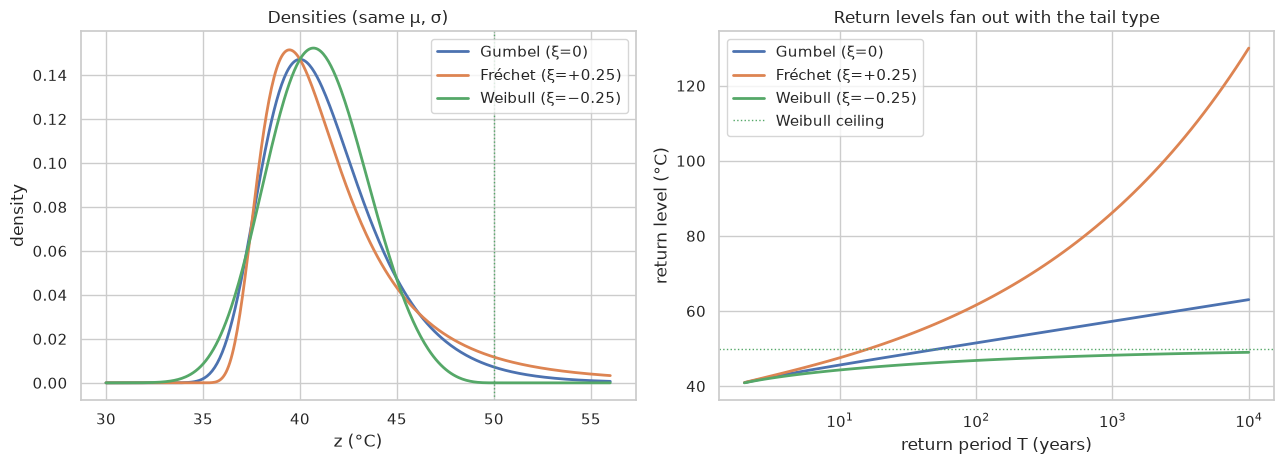

In [3]:
loc0, scale0 = 40.0, 2.5
families = {
    "Gumbel (ξ=0)":    Gumbel(loc=loc0, scale=scale0),
    "Fréchet (ξ=+0.25)": Frechet(loc=loc0, scale=scale0, concentration=0.25),
    "Weibull (ξ=−0.25)": Weibull(loc=loc0, scale=scale0, concentration=-0.25),
}
colors = dict(zip(families, sns.color_palette("deep", 3)))

grid = jnp.linspace(30, 56, 400)
periods = jnp.logspace(np.log10(2), 4, 80)     # up to 10 000 years

fig, (axd, axr) = plt.subplots(1, 2, figsize=(13, 4.8))
for name, dist in families.items():
    axd.plot(grid, jnp.exp(dist.log_prob(grid)), color=colors[name], lw=2, label=name)
    axr.plot(np.asarray(periods), np.asarray(dist.return_level(periods)),
             color=colors[name], lw=2, label=name)
axd.axvline(loc0 + scale0 / 0.25, color=colors["Weibull (ξ=−0.25)"], ls=":", lw=1)
axd.set(xlabel="z (°C)", ylabel="density", title="Densities (same μ, σ)")
axd.legend()
axr.axhline(loc0 + scale0 / 0.25, color=colors["Weibull (ξ=−0.25)"], ls=":", lw=1,
            label="Weibull ceiling")
axr.set_xscale("log")
axr.set(xlabel="return period T (years)", ylabel="return level (°C)",
        title="Return levels fan out with the tail type")
axr.legend()
fig.tight_layout()
plt.show()

## Three families, one dataset

Now the empirical puzzle. We take a real station's annual maxima and fit each
type by maximum likelihood, then compare the in-sample fits.

In [4]:
maxima, stations, years, is_real = data.load_annual_maxima(min_periods=300, min_years=20)
order = np.isfinite(maxima).sum(1) + np.nan_to_num(np.nanmean(maxima, axis=1)) / 1e3
sidx = int(np.argmax(order))
lon, lat = float(stations[sidx, 0]), float(stations[sidx, 1])
city, dist0 = nearest_city(lon, lat)
place = city if dist0 < 12 else f"near {city}"
m_ = np.isfinite(maxima[sidx])
y = jnp.asarray(maxima[sidx][m_]); y_np = np.asarray(y); m = y_np.size
print("source:", "REAL CDS" if is_real else "synthetic", "| station:", place,
      f"({m} annual maxima)")


def mle(neg_log_lik, init, steps=800):
    opt = optax.adam(0.05); state = opt.init(init)
    def step(carry, _):
        p, state = carry
        g = jax.grad(neg_log_lik)(p)
        upd, state = opt.update(g, state, p)
        return (optax.apply_updates(p, upd), state), None
    (p, _), _ = jax.lax.scan(step, (init, state), None, length=steps)
    return p

ymean, ystd, lystd = float(y.mean()), float(y.std()), float(jnp.log(y.std()))

def nll_gum(p):
    mu, ls = p
    return -Gumbel(loc=mu, scale=jnp.exp(ls)).log_prob(y).sum()
def nll_fre(p):
    mu, ls, lx = p
    return -Frechet(loc=mu, scale=jnp.exp(ls), concentration=jnp.exp(lx)).log_prob(y).sum()
def nll_wei(p):
    mu, ls, lx = p
    return -Weibull(loc=mu, scale=jnp.exp(ls), concentration=-jnp.exp(lx)).log_prob(y).sum()

pg = mle(nll_gum, (jnp.array(ymean), jnp.array(lystd)))
pf = mle(nll_fre, (jnp.array(ymean), jnp.array(lystd), jnp.array(np.log(0.1))))
pw = mle(nll_wei, (jnp.array(ymean), jnp.array(lystd), jnp.array(np.log(0.1))))

fits = {
    "Gumbel":  (Gumbel(loc=pg[0], scale=jnp.exp(pg[1])), 2, -float(nll_gum(pg)), 0.0),
    "Fréchet": (Frechet(loc=pf[0], scale=jnp.exp(pf[1]), concentration=jnp.exp(pf[2])),
                3, -float(nll_fre(pf)), float(jnp.exp(pf[2]))),
    "Weibull": (Weibull(loc=pw[0], scale=jnp.exp(pw[1]), concentration=-jnp.exp(pw[2])),
                3, -float(nll_wei(pw)), -float(jnp.exp(pw[2]))),
}
fam_colors = dict(zip(fits, sns.color_palette("deep", 3)))

source: synthetic | station: near Cáceres (75 annual maxima)


**In-sample, they are nearly indistinguishable** — the fitted densities lie almost on top of one another, and the goodness-of-fit scores barely differ:

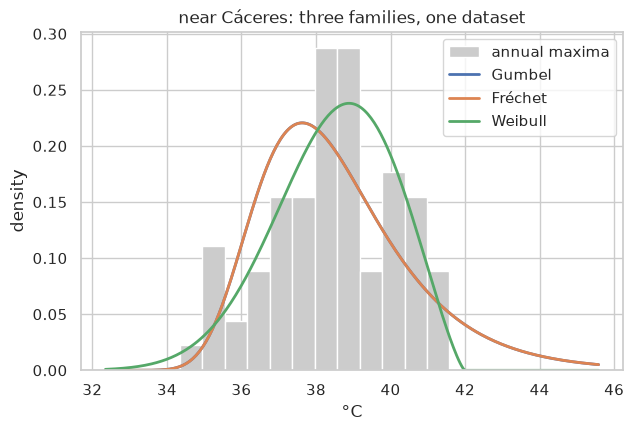

            ξ̂  log-lik      AIC     KS
family                                 
Gumbel   0.000 -150.989  305.979  0.111
Fréchet  0.001 -151.018  308.037  0.111
Weibull -0.435 -141.006  288.012  0.061


In [5]:
zs = np.sort(y_np)
p_emp = (np.arange(1, m + 1) - 0.5) / m
gx = jnp.linspace(zs.min() - 2, zs.max() + 4, 300)

fig, ax = plt.subplots(figsize=(7, 4.4))
ax.hist(y_np, bins=12, density=True, color="0.8", label="annual maxima")
rows = []
for name, (dist, k, logL, xi) in fits.items():
    ax.plot(gx, jnp.exp(dist.log_prob(gx)), color=fam_colors[name], lw=2, label=name)
    ks = float(np.max(np.abs(np.asarray(dist.cdf(jnp.asarray(zs))) - p_emp)))
    rows.append((name, xi, logL, 2 * k - 2 * logL, ks))
ax.set(xlabel="°C", ylabel="density", title=f"{place}: three families, one dataset")
ax.legend()
plt.show()

gof = pd.DataFrame(rows, columns=["family", "ξ̂", "log-lik", "AIC", "KS"]).set_index("family")
print(gof.round(3).to_string())

## ...but they predict different extremes

The catch appears only when we **extrapolate**. The same three fitted models —
indistinguishable on the data — diverge at long return periods: Weibull bends to
its finite ceiling while Fréchet/Gumbel keep climbing. The choice of tail type we
*could not make* from the data is the choice that sets the rarest design values.

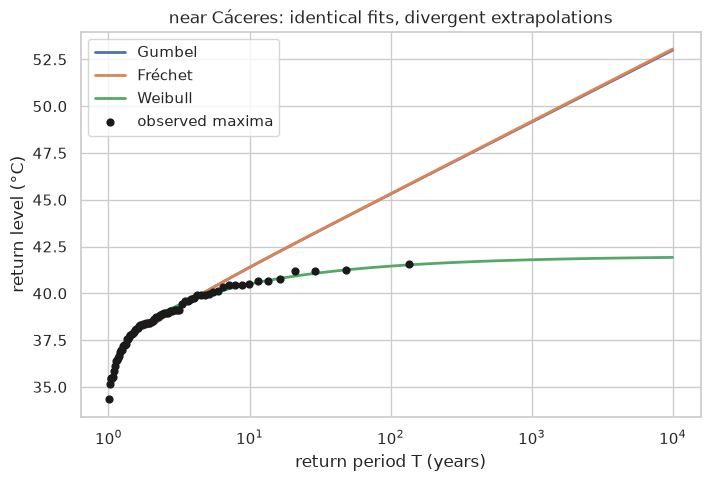

In [6]:
periods = jnp.logspace(np.log10(2), 4, 80)
emp_T = 1.0 / (1.0 - (np.arange(1, m + 1) - 0.44) / (m + 0.12))

fig, ax = plt.subplots(figsize=(8, 5))
for name, (dist, *_) in fits.items():
    ax.plot(np.asarray(periods), np.asarray(dist.return_level(periods)),
            color=fam_colors[name], lw=2, label=name)
ax.scatter(emp_T, zs, color="k", s=24, zorder=5, label="observed maxima")
ax.set_xscale("log")
ax.set(xlabel="return period T (years)", ylabel="return level (°C)",
       title=f"{place}: identical fits, divergent extrapolations")
ax.legend()
plt.show()

## The shape parameter is weakly identified

Why can't the data choose? Because $\xi$ is **weakly identified** from a few
dozen maxima. Two views make this concrete.

**Bayesian.** The full-GEV posterior for $\xi$ straddles zero, putting real mass
in all three regimes — so the data are genuinely consistent with Gumbel, Fréchet
*and* Weibull.

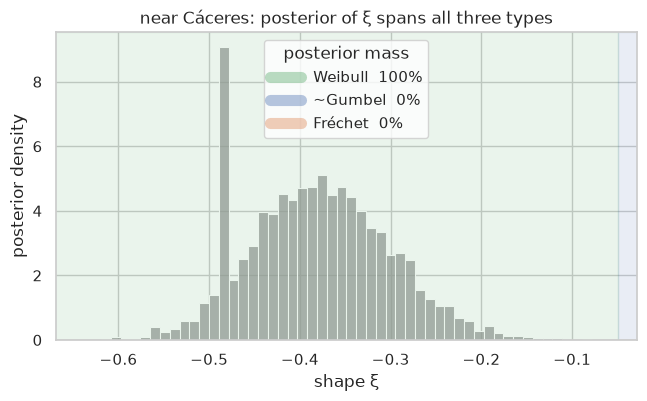

In [7]:
def gev_model(obs):
    mu = numpyro.sample("mu", ndist.Normal(ymean, 5.0))
    sigma = numpyro.sample("sigma", ndist.HalfNormal(ystd))
    xi = numpyro.sample("xi", ndist.Normal(0.0, 0.25))
    numpyro.sample("obs", GEV(loc=mu, scale=sigma, concentration=xi), obs=obs)

mcmc = MCMC(NUTS(gev_model, target_accept_prob=0.95, init_strategy=init_to_median),
            num_warmup=1500, num_samples=2000, num_chains=2,
            chain_method="vectorized", progress_bar=False)
mcmc.run(jr.PRNGKey(0), y)
xi_post = np.asarray(mcmc.get_samples()["xi"])
p_neg, p_zero, p_pos = (np.mean(xi_post < -0.05),
                        np.mean(np.abs(xi_post) <= 0.05),
                        np.mean(xi_post > 0.05))

fig, ax = plt.subplots(figsize=(7.5, 4))
sns.histplot(xi_post, bins=50, stat="density", color="0.6", ax=ax)
for lo, hi, c, lab in [(-1, -0.05, fam_colors["Weibull"], f"Weibull  {p_neg:.0%}"),
                       (-0.05, 0.05, fam_colors["Gumbel"], f"~Gumbel  {p_zero:.0%}"),
                       (0.05, 1, fam_colors["Fréchet"], f"Fréchet  {p_pos:.0%}")]:
    ax.axvspan(lo, hi, color=c, alpha=0.12)
    ax.plot([], [], color=c, lw=8, alpha=0.4, label=lab)
ax.axvline(0, color="k", lw=1)
ax.set(xlim=(xi_post.min() - 0.05, xi_post.max() + 0.05), xlabel="shape ξ",
       ylabel="posterior density", title=f"{place}: posterior of ξ spans all three types")
ax.legend(title="posterior mass")
plt.show()

**Frequentist / small-sample.** Even when the truth *is* a definite type, a short
record cannot recover it. We simulate many records of the same length from a
known mildly-Fréchet GEV ($\xi=0.15$) and re-estimate $\xi$ each time: the
sampling distribution of $\hat\xi$ is broad and routinely crosses into the wrong
regime.

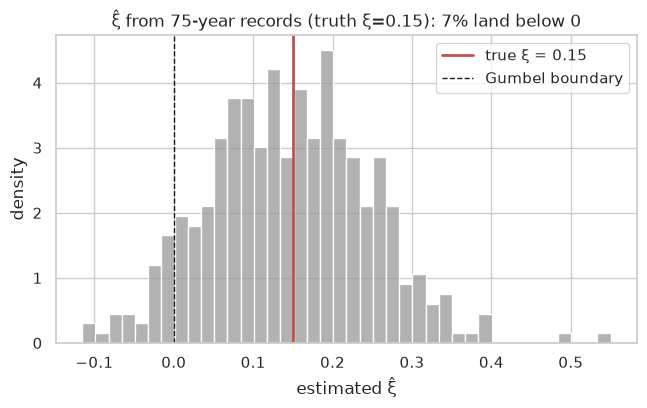

In [8]:
xi_true, n_rep = 0.15, 400
truth = GEV(loc=40.0, scale=2.5, concentration=xi_true)
sims = truth.sample(jr.PRNGKey(1), (n_rep, m))      # (n_rep, m) synthetic records

def fit_xi(sample):
    s_mean, s_lstd = jnp.mean(sample), jnp.log(jnp.std(sample))
    def nll(p):
        mu, ls, xi = p
        return -gev_log_prob(sample, mu, jnp.exp(ls), xi).sum()
    p = mle(nll, (s_mean, s_lstd, jnp.array(0.0)))
    return p[2]

xi_hat = np.asarray(jax.vmap(fit_xi)(sims))
frac_wrong_sign = float(np.mean(xi_hat < 0))

fig, ax = plt.subplots(figsize=(7.5, 4))
sns.histplot(xi_hat, bins=40, stat="density", color="0.6", ax=ax)
ax.axvline(xi_true, color="#C44E52", lw=2, label=f"true ξ = {xi_true}")
ax.axvline(0, color="k", lw=1, ls="--", label="Gumbel boundary")
ax.set(xlabel="estimated ξ̂", ylabel="density",
       title=f"ξ̂ from {m}-year records (truth ξ={xi_true}): "
             f"{frac_wrong_sign:.0%} land below 0")
ax.legend()
plt.show()

## Recap & where next

The GEV's three faces — Gumbel, Fréchet, Weibull — are selected by the sign of
$\xi$, and that sign governs whether extremes are bounded and how heavy the tail
is. Yet $\xi$ is **weakly identified**: families that are indistinguishable on a
station's record imply sharply different rare-event predictions, the posterior
for $\xi$ spans all three types, and short-record estimates $\hat\xi$ scatter
across the boundary.

This is the core motivation for the rest of the curriculum. A single station
simply does not contain enough extremes to fix its tail. The fix is to **borrow
strength across space**: neighbouring stations share a climate, so pooling their
maxima through a spatial Gaussian process sharpens $\xi$ (and every return level
that depends on it). We build toward that next, starting by fitting *every*
station independently in [](../02_pooling/04_many_stations_independent.ipynb) to
see the noise we need to tame.